In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [2]:
print(tf.config.list_physical_devices('GPU'))
print(len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1


In [3]:
# Set dataset path
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [4]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  60


In [5]:
train_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [6]:
val_datagen = ImageDataGenerator()

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [7]:
# Load ResNet50 without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (optional: useful if using pretrained weights)
base_model.trainable = False  # Set to True if you want to fine-tune later

# Custom head for classification
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Instead of Flatten, use GAP for better generalization
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout to reduce overfitting
output = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer

# Define the final model
model = Model(inputs=base_model.input, outputs=output)

In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1_conv[0][0]                 
______________________________________________________________________________________________

In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Lower LR for better training stability
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/60
184/184 [==============================] - 76s 324ms/step - loss: 0.9771 - accuracy: 0.6722 - val_loss: 0.2608 - val_accuracy: 0.9483
Epoch 2/60
184/184 [==============================] - 46s 249ms/step - loss: 0.2892 - accuracy: 0.9144 - val_loss: 0.1202 - val_accuracy: 0.9775
Epoch 3/60
184/184 [==============================] - 46s 249ms/step - loss: 0.1669 - accuracy: 0.9500 - val_loss: 0.0797 - val_accuracy: 0.9850
Epoch 4/60
184/184 [==============================] - 45s 241ms/step - loss: 0.1198 - accuracy: 0.9676 - val_loss: 0.0563 - val_accuracy: 0.9905
Epoch 5/60
184/184 [==============================] - 46s 249ms/step - loss: 0.0920 - accuracy: 0.9763 - val_loss: 0.0434 - val_accuracy: 0.9932
Epoch 6/60
184/184 [==============================] - 46s 250ms/step - loss: 0.0702 - accuracy: 0.9807 - val_loss: 0.0366 - val_accuracy: 0.9925
Epoch 7/60
184/184 [==============================] - 46s 250ms/step - loss: 0.0568 - accuracy: 0.9852 - val_loss: 0.0313 - val_ac

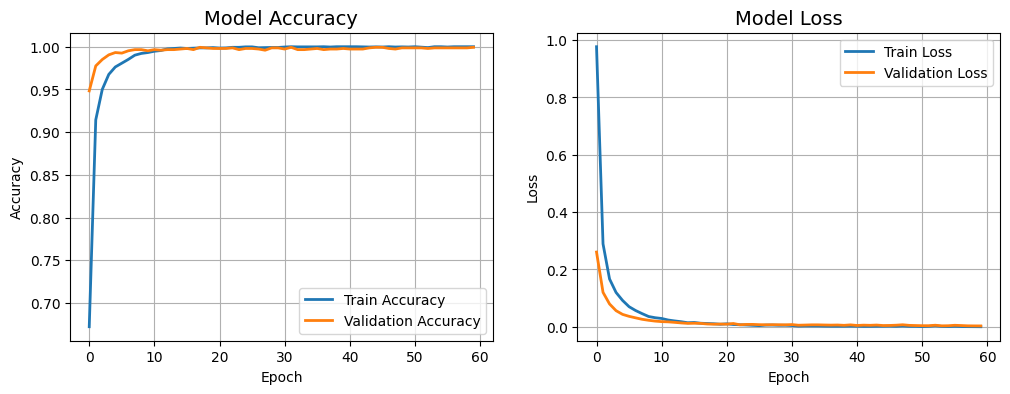

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [12]:
# Evaluate model
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # Fix tf.argmax issue

Found 190 images belonging to 8 classes.


In [13]:
# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Plot confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        21
           2       0.96      1.00      0.98        25
           3       0.96      1.00      0.98        23
           4       0.91      1.00      0.95        21
           5       1.00      0.96      0.98        23
           6       1.00      0.96      0.98        26
           7       1.00      0.91      0.95        23

    accuracy                           0.98       190
   macro avg       0.98      0.98      0.98       190
weighted avg       0.98      0.98      0.98       190



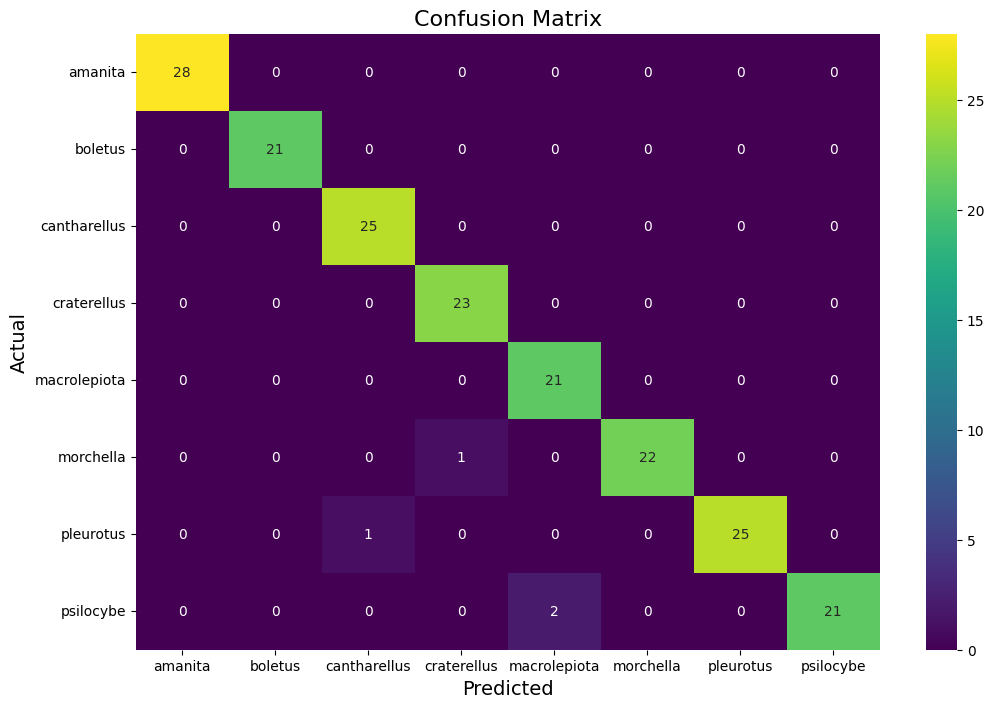

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [15]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [16]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_70_ADAM.ipynb


In [ ]:
os._exit(00)